In [40]:
import cv2
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
pivot_x = 947      #OG pivot
pivot_y = 180

#Starting values
L1 = 20.5 #cm  - meten met meetlat
QL1 = 0.05 #cm  - Onzekerheid van meetlat

L2 = 16 #cm
QL2 = 0.05 #cm 

m1 =  0.2703 #kg - Meten op weegschaal 
Qm1 = 0.00005 #kg - onzekerheid van weegschaal 

m2 = 0.2002 #kg
Qm2 = 0.00005 #kg 

Fixed_pivot_coords = np.array([[916, 316], [924, 315], [922, 314], [933, 306], [935,311], [930,312], [931,311], [924,311],[936,311],[930,311],[926,319],[915,313],[906,313]], dtype=np.float32)

first_vid, last_vid = 8, 20

# column names in input csv 
col_theta1 = "theta1_rad_filled"
col_theta2 = "theta2_rel_rad_filled"   

#Thresholds for detecting the start of the pendulum motion and ending measurement. 
threshold_deg = 10   # arm 1 must deviate this much from its resting angle
duration_s = 10      # seconds to keep after that moment
n_ref = 10           # number of first valid frames used to determine the resting angle


start_angles = []
scale_list = []

for i, vid_nr in enumerate(range(first_vid, last_vid + 1)):
    filename = f"Meetdag 2/Meetdag2_Vid{vid_nr}_Total.csv"
    coords = pd.read_csv(filename)

    new_pivot_x, new_pivot_y = Fixed_pivot_coords[i]

    theta1_old = coords[col_theta1].to_numpy(dtype=float)
    theta2_old = coords[col_theta2].to_numpy(dtype=float)

    Gx_meas = coords["Gx"].to_numpy(dtype=float)
    Gy_meas = coords["Gy"].to_numpy(dtype=float)
    Bx_meas = coords["Bx"].to_numpy(dtype=float)
    By_meas = coords["By"].to_numpy(dtype=float)

    # arm lengths in pixels (measured frames only)
    r1_px = np.nanmedian(np.hypot(Gx_meas - new_pivot_x, Gy_meas - new_pivot_y))
    L2_px = np.nanmedian(np.hypot(Bx_meas - Gx_meas, By_meas - Gy_meas))

    # pixels per cm
    s1 = r1_px / L1
    s2 = L2_px / L2
    Qs1 = s1 * QL1 / L1
    Qs2 = s2 * QL2 / L2
    w1, w2 = 1 / Qs1**2, 1 / Qs2**2
    scale = (w1 * s1 + w2 * s2) / (w1 + w2)
    Qscale = 1 / np.sqrt(w1 + w2)
    scale_list.append((filename, scale, Qscale, s1, s2))

    r1_old = (pd.Series(np.hypot(Gx_meas - pivot_x, Gy_meas - pivot_y))
              .interpolate(limit_area="inside").to_numpy())

    Gx_rec = pivot_x + r1_old * np.sin(theta1_old)
    Gy_rec = pivot_y + r1_old * np.cos(theta1_old)
    Gx = np.where(np.isnan(Gx_meas), Gx_rec, Gx_meas)
    Gy = np.where(np.isnan(Gy_meas), Gy_rec, Gy_meas)

    Bx_rec = Gx + L2_px * np.sin(theta2_old)
    By_rec = Gy + L2_px * np.cos(theta2_old)
    Bx = np.where(np.isnan(Bx_meas), Bx_rec, Bx_meas)
    By = np.where(np.isnan(By_meas), By_rec, By_meas)

    theta1_new = np.arctan2(Gx - new_pivot_x, Gy - new_pivot_y)
    theta2_new = np.arctan2(Bx - Gx, By - Gy)

    r1_new = np.hypot(Gx - new_pivot_x, Gy - new_pivot_y)
    spread = np.nanstd(r1_new) / np.nanmean(r1_new)

    t = coords["time_s"].to_numpy(dtype=float)
    omega1 = np.gradient(np.unwrap(theta1_new), t)
    omega2 = np.gradient(np.unwrap(theta2_new), t)

    L1_m, L2_m = L1 / 100, L2 / 100
    delta = theta1_new - theta2_new
    p1 = (m1/3 + m2) * L1_m**2 * omega1 + 0.5 * m2 * L1_m * L2_m * omega2 * np.cos(delta)
    p2 = (m2/3) * L2_m**2 * omega2 + 0.5 * m2 * L1_m * L2_m * omega1 * np.cos(delta)

    coords_new = pd.DataFrame({
        "frame": coords["frame"],
        "time_s": coords["time_s"],
        "Gx": Gx, "Gy": Gy, "Bx": Bx, "By": By,
        "theta1_rad": theta1_new,
        "theta2_rad": theta2_new,
        "theta1_deg": np.degrees(theta1_new),
        "theta2_deg": np.degrees(theta2_new),
        "omega1_rad_s": omega1,
        "omega2_rad_s": omega2,
        "p1": p1,
        "p2": p2
    })
    for c in coords.columns:
        if c.endswith("_interpolated"):
            coords_new[c] = coords[c]

    # --- NEW: crop to the swing: from 15 deg away from the resting angle, until +10 s ---
    theta_ref = coords_new["theta1_deg"].dropna().iloc[:n_ref].median()   # resting angle of arm 1
    deviation = (coords_new["theta1_deg"] - theta_ref + 180) % 360 - 180  # wrapped to +-180
    moving = deviation.abs() >= threshold_deg

    if not moving.any():
        print(f"{filename}: arm 1 never deviates {threshold_deg} deg from its resting angle, skipped")
        continue

    t_start = coords_new.loc[moving.idxmax(), "time_s"]    # first frame that passes the threshold
    in_window = (coords_new["time_s"] >= t_start) & (coords_new["time_s"] <= t_start + duration_s)
    coords_new = coords_new[in_window].reset_index(drop=True)

    out_name = f"Meting_processed_Vid{i + 1}.csv"
    coords_new.to_csv(out_name, index=False)

    start_angles.append((out_name, filename, theta_ref, t_start))

    length = coords_new["time_s"].iloc[-1] - coords_new["time_s"].iloc[0]
    print(f"{filename} -> {out_name} | L2={L2_px:.1f}px, arm 1 length spread={spread:.1%}, "
          f"start at {t_start:.2f} s, kept {length:.2f} s")

print("\nStarting angle theta1 per file:")
for out_name, src, ang, t0 in start_angles:
    print(f"{out_name} (from {src}): {ang:.2f} deg (swing starts at {t0:.2f} s)")

print()

for src, sc, Qsc, s1, s2 in scale_list:
    print(f"{src}: {sc:.2f} +- {Qsc:.2f} px/cm  (arm 1: {s1:.2f}, arm 2: {s2:.2f}, "
          f"difference {abs(s1 - s2) / sc:.1%})")

Meetdag 2/Meetdag2_Vid8_Total.csv -> Meting_processed_Vid1.csv | L2=239.0px, arm 1 length spread=0.5%, start at 1.62 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid9_Total.csv -> Meting_processed_Vid2.csv | L2=238.5px, arm 1 length spread=0.8%, start at 3.20 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid10_Total.csv -> Meting_processed_Vid3.csv | L2=238.8px, arm 1 length spread=0.6%, start at 0.97 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid11_Total.csv -> Meting_processed_Vid4.csv | L2=239.0px, arm 1 length spread=0.7%, start at 0.93 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid12_Total.csv -> Meting_processed_Vid5.csv | L2=239.7px, arm 1 length spread=0.8%, start at 1.05 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid13_Total.csv -> Meting_processed_Vid6.csv | L2=238.4px, arm 1 length spread=1.5%, start at 1.12 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid14_Total.csv -> Meting_processed_Vid7.csv | L2=238.6px, arm 1 length spread=1.1%, start at 0.88 s, kept 10.00 s
Meetdag 2/Meetdag2_Vid15_Total.csv -> Meting_processed_Vid8.csv 

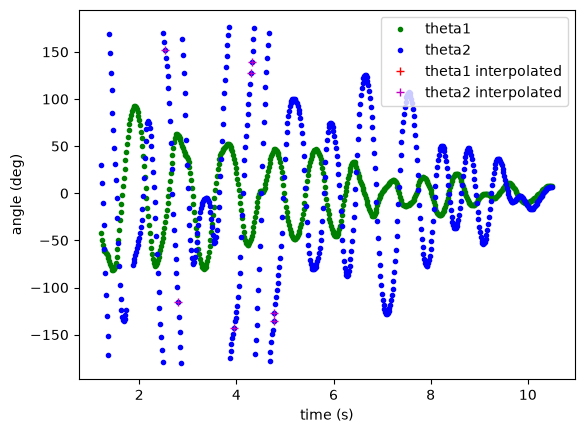

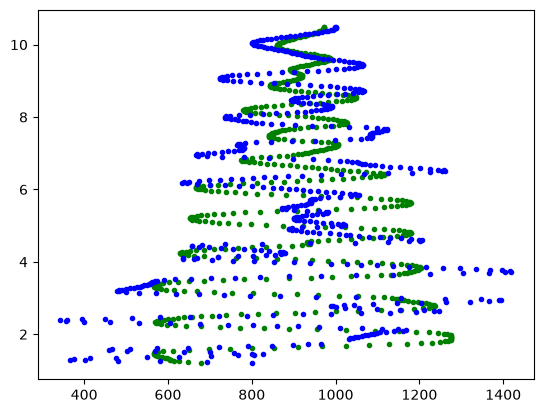

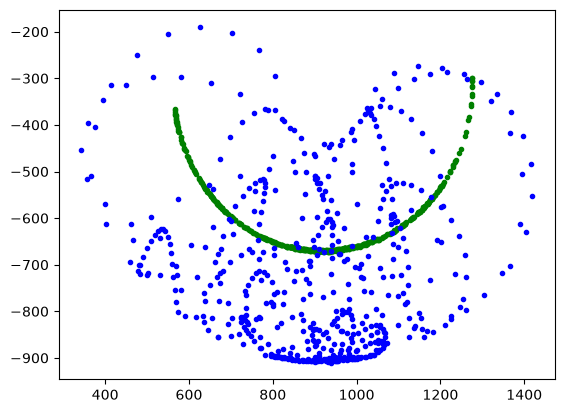

In [51]:
coords= pd.read_csv("Meting_processed_Vid3.csv")

t_start = 1.2    # seconds
t_end = 10.5     # seconds

coords = coords[(coords["time_s"] >= t_start) & (coords["time_s"] <= t_end)].reset_index(drop=True)


tijd = coords["time_s"]
theta_1_full = coords["theta1_deg"]
theta_2_full = coords["theta2_deg"]
theta_1_interpolated = np.where(coords["theta1_interpolated"], coords["theta1_deg"], np.nan)
theta_2_interpolated = np.where(coords["theta2_rel_interpolated"], coords["theta2_deg"], np.nan)

x_m_g = coords["Gx"]
y_m_g = -coords["Gy"]
x_m_b = coords["Bx"]
y_m_b = -coords["By"]

plt.figure()
plt.plot(tijd, theta_1_full, "g.", label="theta1")
plt.plot(tijd, theta_2_full, "b.", label="theta2")
plt.plot(tijd, theta_1_interpolated, "r+", label="theta1 interpolated")
plt.plot(tijd, theta_2_interpolated, "m+", label="theta2 interpolated")
plt.xlabel("time (s)"); plt.ylabel("angle (deg)"); plt.legend();
plt.show()


plt.figure()
plt.plot(x_m_g,tijd,"g.")
plt.plot(x_m_b,tijd,"b.")
plt.show()

plt.figure()
plt.plot(x_m_g,y_m_g,"g.")
plt.plot(x_m_b,y_m_b,"b.")
plt.show()